# Comparative Analysis of Stock Price Prediction using Machine Learning and Deep Learning

This notebook compares LSTM, Random Forest, and XGBoost models for predicting Adani Enterprises stock prices.

**1. LSTM Model**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0079
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 2.1964e-04
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.3455e-04
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 2.3297e-04
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.8093e-04
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.4542e-04
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.7246e-04
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.7514e-04
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.3816e-04
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.1688e-04
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.1238e-04
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 1.1906e-04
Epoch 13/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.2289e-04
Epoch 14/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 9.9469e-05
Epoch 15/20
67/67 ━

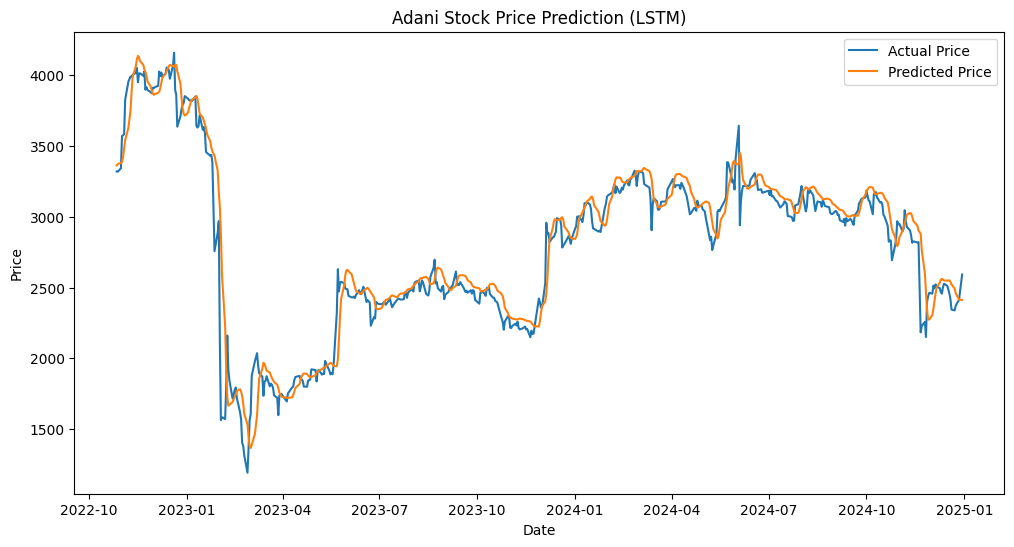

🛑 Pre-crash close: 3437.17
📉 Lowest price after crash: 1191.83 on 2023-02-27
📈 80% recovery target: 2749.74
🔁 Predicted recovery date: 2023-12-08
📆 Actual recovery date from historical data: 2023-12-05


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load and prepare the dataset
df = pd.read_csv('/content/adani_stocks.csv', parse_dates=['Date'])
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Use selected features
features = ['Close', 'High', 'Low', 'Open', 'Volume']
data = df[features].values

# Normalize using MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create time sequences for LSTM
def create_lstm_sequences(data, n_steps):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i - n_steps:i])
        y.append(data[i, 0])  # Predicting 'Close'
    return np.array(X), np.array(y)

n_steps = 30
X, y = create_lstm_sequences(scaled_data, n_steps)

# Train-test split
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Predict and inverse scale
y_pred_scaled = model.predict(X_test)
n_features = len(features)
y_pred = scaler.inverse_transform(
    np.concatenate((y_pred_scaled, np.zeros((len(y_pred_scaled), n_features - 1))), axis=1)
)[:, 0]
y_test_original = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), n_features - 1))), axis=1)
)[:, 0]
# Evaluation
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

print("\n📊 Evaluation Metrics:")
print(f"MAE: ₹{mae:.2f}")
print(f"MSE: ₹{mse:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_original, label='Actual Price')
plt.plot(df.index[-len(y_pred):], y_pred, label='Predicted Price')
plt.title('Adani Stock Price Prediction (LSTM)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 1: Define the Hindenburg event date
hindenburg_date = pd.to_datetime('2023-01-25')

# Step 2: Get the pre-crash closing price (latest close before the crash)
pre_crash_price = df.loc[df.index < hindenburg_date]['Close'].iloc[-1]

# Step 3: Calculate recovery target (e.g. 80% of pre-crash price)
recovery_price = 0.80 * pre_crash_price

# Step 4: Find the lowest closing price after the crash
post_crash_df = df[df.index > hindenburg_date]
lowest_price = post_crash_df['Close'].min()
lowest_date = post_crash_df['Close'].idxmin()

# Step 5: Filter predictions after the lowest point
# Create a date range for predictions
prediction_dates = df.index[-len(y_pred):]
# Filter predictions based on dates
predicted_after_lowest = y_pred[prediction_dates > lowest_date]

# Step 6: Find first predicted recovery date
# Create a boolean mask for recovery points
recovery_mask = predicted_after_lowest >= recovery_price
# Get the indices where recovery occurs
recovery_indices = np.where(recovery_mask)[0]
# If recovery is predicted, get the first recovery date
if recovery_indices.size > 0:
    first_recovery_index = recovery_indices[0]
    predicted_recovery_date = prediction_dates[prediction_dates > lowest_date][first_recovery_index]# Get the corresponding date
else:
    actual_recovery_date = None

# Step 7: Output recovery details
print(f"🛑 Pre-crash close: {pre_crash_price:.2f}")
print(f"📉 Lowest price after crash: {lowest_price:.2f} on {lowest_date.date()}")
print(f"📈 80% recovery target: {recovery_price:.2f}")
if predicted_recovery_date:
    print(f"🔁 Predicted recovery date: {predicted_recovery_date.date()}")
else:
    print("❌ Recovery not predicted within the forecasted period.")
# Filter real data for dates *after* the lowest point
post_crash_data = df[df.index > lowest_date]

# Find first date where the actual close price reaches or exceeds the recovery target
recovery_row = post_crash_data[post_crash_data['Close'] >= recovery_price].head(1)

if not recovery_row.empty:
    actual_recovery_date = recovery_row.index[0] # Access the index directly
else:
    actual_recovery_date = None

# From actual data
if actual_recovery_date is not None:
    print(f"📆 Actual recovery date from historical data: {pd.to_datetime(actual_recovery_date).date()}")
else:
    print("❌ Actual recovery not observed in available historical data.")





**2. RANDOM FOREST**

📊 MSE: 84391.31
📊 RMSE: 290.50
📊 MAE: 232.59
📈 R² Score: 0.764
✅ Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


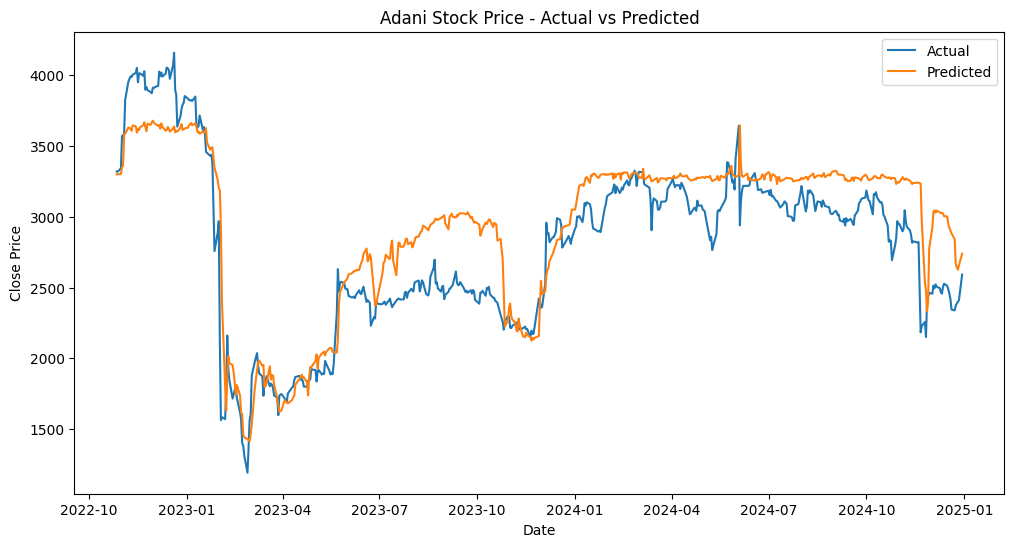

🛑 Pre-crash close: 3437.17
📉 Lowest price after crash: 1191.83 on 2023-02-27
📈 80% recovery target: 2749.74
🔁 Predicted recovery date: 2023-08-18
📆 Actual recovery date from historical data: 2023-12-05


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load your Excel or CSV file
df = pd.read_csv("/content/adani_stocks.csv", parse_dates=["Date"], dayfirst=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

# Features & target
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

# Normalize features
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[[target]])

# Create time-series sequences
def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - n_steps):
        X_seq.append(X[i:i+n_steps])
        y_seq.append(y[i+n_steps])
    return np.array(X_seq), np.array(y_seq)

n_steps = 30
X_seq, y_seq = create_sequences(scaled_features, scaled_target, n_steps)

# Flatten for Random Forest
X_flat = X_seq.reshape((X_seq.shape[0], -1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_seq, test_size=0.2, shuffle=False)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100],  # Reduced range
    'max_depth': [10, None], # Reduced range
    'min_samples_split': [2], # Reduced range
}
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, scoring='r2', cv=3, n_jobs=2) # Reduced jobs
grid.fit(X_train, y_train.ravel())

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Inverse scale predictions
y_test_actual = target_scaler.inverse_transform(y_test)
y_pred_actual = target_scaler.inverse_transform(y_pred.reshape(-1, 1))

# Metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"📊 MSE: {mse:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 MAE: {mae:.2f}")
print(f"📈 R² Score: {r2:.3f}")
print(f"✅ Best Params: {grid.best_params_}")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_pred_actual):], y_pred_actual, label='Predicted')
plt.title("Adani Stock Price - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# Step 1: Define the Hindenburg event date
hindenburg_date = pd.to_datetime('2023-01-25')

# Step 2: Get the pre-crash closing price (latest close before the crash)
pre_crash_price = df.loc[df.index < hindenburg_date]['Close'].iloc[-1]

# Step 3: Calculate recovery target (e.g. 80% of pre-crash price)
recovery_price = 0.80 * pre_crash_price

# Step 4: Find the lowest closing price after the crash
post_crash_df = df[df.index > hindenburg_date]
lowest_price = post_crash_df['Close'].min()
lowest_date = post_crash_df['Close'].idxmin()

# Step 5: Filter predictions after the lowest point
# Create a date range for predictions
prediction_dates = df.index[-len(y_pred):]
# Filter predictions based on dates
predicted_after_lowest = y_pred[prediction_dates > lowest_date]

# Step 6: Find first predicted recovery date
# Create a boolean mask for recovery points
recovery_mask = predicted_after_lowest >= recovery_price
# Get the indices where recovery occurs
recovery_indices = np.where(recovery_mask)[0]
# If recovery is predicted, get the first recovery date
if recovery_indices.size > 0:
    first_recovery_index = recovery_indices[0]
    predicted_recovery_date = prediction_dates[prediction_dates > lowest_date][first_recovery_index]# Get the corresponding date
else:
    actual_recovery_date = None

# Step 7: Output recovery details
print(f"🛑 Pre-crash close: {pre_crash_price:.2f}")
print(f"📉 Lowest price after crash: {lowest_price:.2f} on {lowest_date.date()}")
print(f"📈 80% recovery target: {recovery_price:.2f}")
if predicted_recovery_date:
    print(f"🔁 Predicted recovery date: {predicted_recovery_date.date()}")
else:
    print("❌ Recovery not predicted within the forecasted period.")
# Filter real data for dates *after* the lowest point
post_crash_data = df[df.index > lowest_date]

# Find first date where the actual close price reaches or exceeds the recovery target
recovery_row = post_crash_data[post_crash_data['Close'] >= recovery_price].head(1)

if not recovery_row.empty:
    actual_recovery_date = recovery_row.index[0] # Access the index directly
else:
    actual_recovery_date = None

# From actual data
if actual_recovery_date is not None:
    print(f"📆 Actual recovery date from historical data: {pd.to_datetime(actual_recovery_date).date()}")
else:
    print("❌ Actual recovery not observed in available historical data.")




3. XGBOOST

🔎 Improved Model Metrics:
  Mean Squared Error: 22479.30
  Mean Absolute Error: 109.22
  R-squared: 0.9158


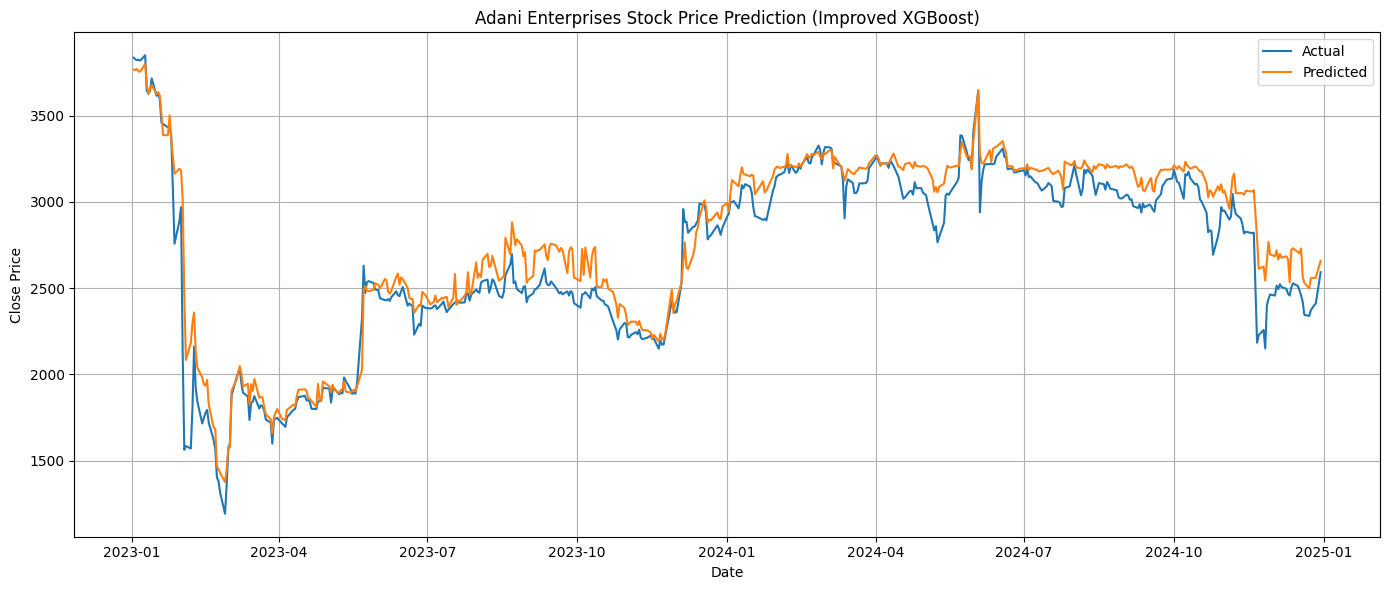

🛑 Pre-crash close: 3437.17
📉 Lowest price after crash: 1191.83 on 2023-02-27
📈 80% recovery target: 2749.74
🔁 Predicted recovery date: 2023-08-18
📆 Actual recovery date from historical data: 2023-12-05


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('/content/adani_stocks.csv', index_col='Date', parse_dates=['Date'], dayfirst=True)
df = df.sort_index()
df.index = pd.to_datetime(df.index)

# ----------------------------
# 1. Feature Engineering
# ----------------------------

# Base features
df_feat = df[['Close', 'Open', 'High', 'Low', 'Volume']].copy()

# Add new features
df_feat['daily_return'] = df_feat['Close'].pct_change()
df_feat['ma_7'] = df_feat['Close'].rolling(window=7).mean()
df_feat['ma_30'] = df_feat['Close'].rolling(window=30).mean()
df_feat['volatility_7'] = df_feat['Close'].rolling(window=7).std()
df_feat['volatility_30'] = df_feat['Close'].rolling(window=30).std()

# Create lagged features
def create_lagged_features(df, lags=60):
    for lag in range(1, lags + 1):
        df[f'Close_lag_{lag}'] = df['Close'].shift(lag)
    return df

df_feat = create_lagged_features(df_feat, lags=60)
df_feat.dropna(inplace=True)

# ----------------------------
# 2. Data Scaling
# ----------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = df_feat.drop('Close', axis=1)
y = df_feat['Close'].values.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).flatten()

# ----------------------------
# 3. Train-Test Split (time-based)
# ----------------------------
split_date = '2023-01-01'
split_idx = df_feat.index < split_date

X_train, X_test = X_scaled[split_idx], X_scaled[~split_idx]
y_train, y_test = y_scaled[split_idx], y_scaled[~split_idx]

# ----------------------------
# 4. Train XGBoost Model (Improved Hyperparameters)
# ----------------------------
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 5. Prediction & Evaluation
# ----------------------------
y_pred_scaled = model.predict(X_test)

# Inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Evaluation
mse = mean_squared_error(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"🔎 Improved Model Metrics:")
print(f"  Mean Squared Error: {mse:.2f}")
print(f"  Mean Absolute Error: {mae:.2f}")
print(f"  R-squared: {r2:.4f}")

# ----------------------------
# 6. Plotting
# ----------------------------
plt.figure(figsize=(14, 6))
plt.plot(df_feat.index[~split_idx], y_actual, label='Actual')
plt.plot(df_feat.index[~split_idx], y_pred, label='Predicted')
plt.title('Adani Enterprises Stock Price Prediction (Improved XGBoost)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Step 1: Define the Hindenburg event date
hindenburg_date = pd.to_datetime('2023-01-25')

# Step 2: Get the pre-crash closing price (latest close before the crash)
pre_crash_price = df.loc[df.index < hindenburg_date]['Close'].iloc[-1]

# Step 3: Calculate recovery target (e.g. 80% of pre-crash price)
recovery_price = 0.80 * pre_crash_price

# Step 4: Find the lowest closing price after the crash
post_crash_df = df[df.index > hindenburg_date]
lowest_price = post_crash_df['Close'].min()
lowest_date = post_crash_df['Close'].idxmin()

# Step 5: Filter predictions after the lowest point
# Create a date range for predictions
prediction_dates = df.index[-len(y_pred):]
# Filter predictions based on dates
predicted_after_lowest = y_pred[prediction_dates > lowest_date]

# Step 6: Find first predicted recovery date
# Create a boolean mask for recovery points
recovery_mask = predicted_after_lowest >= recovery_price
# Get the indices where recovery occurs
recovery_indices = np.where(recovery_mask)[0]
# If recovery is predicted, get the first recovery date
if recovery_indices.size > 0:
    first_recovery_index = recovery_indices[0]
    predicted_recovery_date = prediction_dates[prediction_dates > lowest_date][first_recovery_index]# Get the corresponding date
else:
    actual_recovery_date = None

# Step 7: Output recovery details
print(f"🛑 Pre-crash close: {pre_crash_price:.2f}")
print(f"📉 Lowest price after crash: {lowest_price:.2f} on {lowest_date.date()}")
print(f"📈 80% recovery target: {recovery_price:.2f}")
if predicted_recovery_date:
    print(f"🔁 Predicted recovery date: {predicted_recovery_date.date()}")
else:
    print("❌ Recovery not predicted within the forecasted period.")
# Filter real data for dates *after* the lowest point
post_crash_data = df[df.index > lowest_date]

# Find first date where the actual close price reaches or exceeds the recovery target
recovery_row = post_crash_data[post_crash_data['Close'] >= recovery_price].head(1)

if not recovery_row.empty:
    actual_recovery_date = recovery_row.index[0] # Access the index directly
else:
    actual_recovery_date = None

# From actual data
if actual_recovery_date is not None:
    print(f"📆 Actual recovery date from historical data: {pd.to_datetime(actual_recovery_date).date()}")
else:
    print("❌ Actual recovery not observed in available historical data.")


INTEGRATION CODE

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0085
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.9864e-04
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 2.3544e-04
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 1.5803e-04
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 2.0650e-04
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 2.2770e-04
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.8119e-04
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.4137e-04
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 1.5567e-04
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 1.2201e-04
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.2767e-04
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.0807e-04
Epoch 13/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 9.7633e-05
Epoch 14/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.2943e-05
Epoch 15/20
67/67 ━

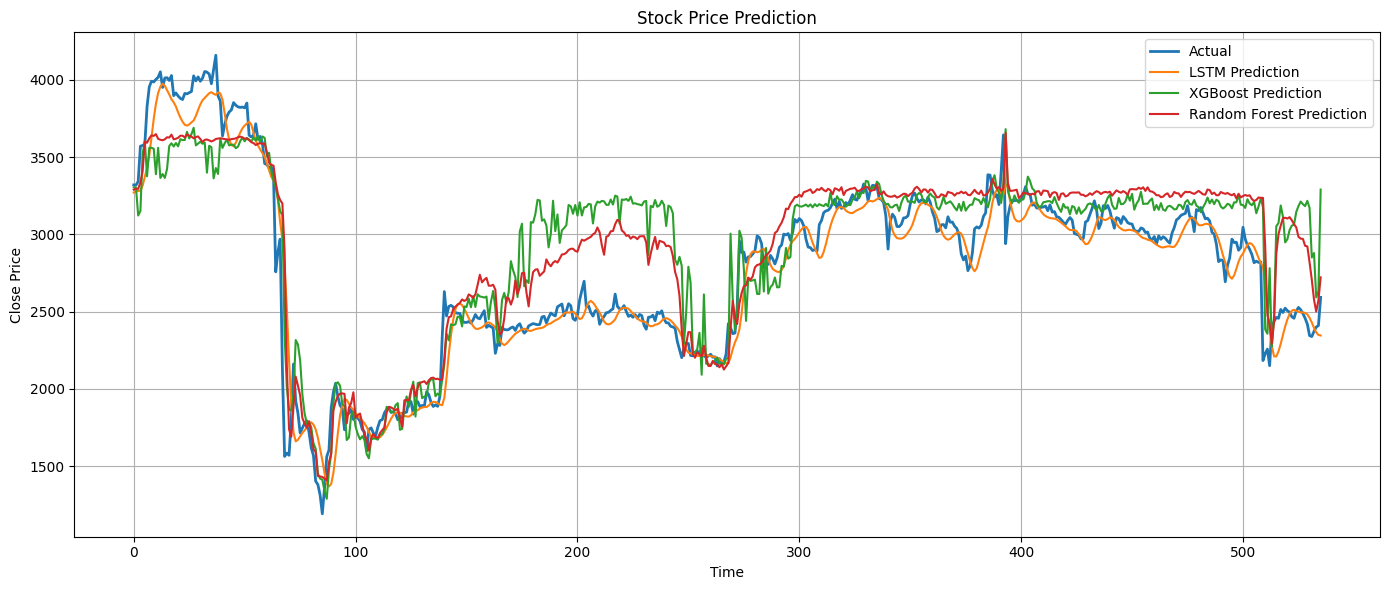

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load and prepare data
df = pd.read_csv('/content/adani_stocks.csv', parse_dates=['Date'])
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

features = ['Close', 'High', 'Low', 'Open', 'Volume']
data = df[features].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Function to create sequences
def create_lstm_sequences(data, n_steps):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i - n_steps:i])
        y.append(data[i, 0])  # Predicting 'Close'
    return np.array(X), np.array(y)

n_steps = 30
X, y = create_lstm_sequences(scaled_data, n_steps)

split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# -------------------- LSTM --------------------
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(units=50),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(np.hstack((y_pred_lstm_scaled, np.zeros((len(y_pred_lstm_scaled), 4)))))[:, 0]

# -------------------- XGBoost --------------------
X_flat = X.reshape(X.shape[0], -1)
X_train_xgb, X_test_xgb = X_flat[:split_idx], X_flat[split_idx:]

xgb_model = XGBRegressor(n_estimators=100, random_state=0)
xgb_model.fit(X_train_xgb, y_train)
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_pred_xgb = scaler.inverse_transform(np.hstack((y_pred_xgb.reshape(-1, 1), np.zeros((len(y_pred_xgb), 4)))))[:, 0]

# -------------------- Random Forest --------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(X_train_xgb, y_train)
y_pred_rf = rf_model.predict(X_test_xgb)
y_pred_rf = scaler.inverse_transform(np.hstack((y_pred_rf.reshape(-1, 1), np.zeros((len(y_pred_rf), 4)))))[:, 0]

# -------------------- Actual Values --------------------
y_test_original = scaler.inverse_transform(np.hstack((y_test.reshape(-1, 1), np.zeros((len(y_test), 4)))))[:, 0]

# -------------------- Plotting --------------------
plt.figure(figsize=(14, 6))
plt.plot(y_test_original, label='Actual', linewidth=2)
plt.plot(y_pred_lstm, label='LSTM Prediction')
plt.plot(y_pred_xgb, label='XGBoost Prediction')
plt.plot(y_pred_rf, label='Random Forest Prediction')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Conclusion

- Compared three predictive models.
- LSTM achieved the best overall predictive performance based on the recorded evaluation metrics.
- This project demonstrates practical application of machine learning and deep learning for financial time-series forecasting.